# Assignment 5
* Student: **Danilo Tambone**
* NetID: **PWC25003**

The work contained and presented here is my work and my work alone.

In [1]:
# import modules

import pandas as pd # for data viz and wrangling
import numpy as np # for 'numeric python'
import matplotlib.pyplot as plt # for data viz (more complex than pylab)
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

In [2]:
# mount your google drive
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Predictive Modeling/M5/spotify-2023_modeling.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


1. Read in the dataset and determine how many rows and columns it has.


In [3]:
#how many rows and columns
df.shape

(902, 25)

The dataset has 902 rows and 25 columns

2. The target variable for this dataset is the streams column.  Check the datatype of streams.  If it isn’t already int64, update it.  

In [4]:
# Step 1: Check the initial datatype of the 'streams' column
print("Initial datatype of 'streams':", df['streams'].dtype)

# Step 2: Check if the datatype is already int64, if not, update it
if df['streams'].dtype != 'int64':
    # Convert the column to int64
    df['streams'] = df['streams'].astype('int64')
    print("Datatype successfully updated.")

# Step 3: Verify the change
print("Final datatype of 'streams':", df['streams'].dtype)

Initial datatype of 'streams': float64
Datatype successfully updated.
Final datatype of 'streams': int64


3. Partition the data into a 60/20/20 split.


In [5]:
# Define the target variable
target = 'streams'
features = df.drop(target, axis=1)
target_variable = df[target]

# Split the data into 80% temporary (Train + Val) and 20% test
X_train, X_test, y_train, y_test = train_test_split(features, target_variable, test_size=0.2, random_state=42)

# Split the 80% temporary data into 60% training and 20% validation
# To get 20% of the overall data from the 80% chunk, we use 0.25 (0.25 * 0.80 = 0.20)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

# Print the shapes of the resulting datasets to verify
print("Training set shape:", X_train.shape, y_train.shape)
print("Validation set shape:", X_val.shape, y_val.shape)
print("Test set shape:", X_test.shape, y_test.shape)

Training set shape: (540, 24) (540,)
Validation set shape: (181, 24) (181,)
Test set shape: (181, 24) (181,)


4. Build a linear regression model to predict streams using all predictors except track_name, artist(s)_name, released_year, and released_month.  The first two columns act as unique row identifiers.  The other two columns have been preprocessed into more useful formats.  

In [6]:
# 1. Drop the 4 unneeded columns
cols_to_drop = ['track_name', 'artist(s)_name', 'released_year', 'released_month']
df_model = df.drop(columns=cols_to_drop)

# 2. Create dummy variables for our remaining categorical columns ('mode' and 'released_month_reduced')
# drop_first=True creates n-1 dummy variables (dropping 'High' and 'Major')
df_model = pd.get_dummies(df_model, drop_first=True, dtype=int)

# 3. Define the target variable and updated features
target = 'streams'
features = df_model.drop(target, axis=1)
target_variable = df_model[target]

# 4. Perform our 60/20/20 split again with our updated features
X_train, X_test, y_train, y_test = train_test_split(features, target_variable, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

# --- Linear Regression with Multiple Predictors ---

# Initialize the Linear Regression model
model = LinearRegression()

# Fit the model to the training data
model.fit(X_train, y_train)

# Make predictions on the training, validation, and test sets
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)

# Evaluate the model on the training, validation, and test sets
train_mse = mean_squared_error(y_train, y_train_pred)
val_mse = mean_squared_error(y_val, y_val_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

# Calculate RMSE
train_rmse = np.sqrt(train_mse)
val_rmse = np.sqrt(val_mse)
test_rmse = np.sqrt(test_mse)

train_r2 = r2_score(y_train, y_train_pred)
val_r2 = r2_score(y_val, y_val_pred)
test_r2 = r2_score(y_test, y_test_pred)

# Print the performance metrics
print("Model Performance:")
print(f"  Training Set - RMSE: {train_rmse:.2f}, R-squared: {train_r2:.2f}")
print(f"  Validation Set - RMSE: {val_rmse:.2f}, R-squared: {val_r2:.2f}")
print(f"  Test Set - RMSE: {test_rmse:.2f}, R-squared: {test_r2:.2f}")

# Print the model coefficients and intercept
print("\nModel Coefficients:")
for feature, coef in zip(X_train.columns, model.coef_):
    print(f"  {feature}: {coef:.2f}")

print(f"\nIntercept: {model.intercept_:.2f}")

Model Performance:
  Training Set - RMSE: 249436307.07, R-squared: 0.75
  Validation Set - RMSE: 291967156.93, R-squared: 0.74
  Test Set - RMSE: 253143015.28, R-squared: 0.75

Model Coefficients:
  artist_count: -19530876.06
  Johnson Su Transform to Normal released_year: -140994504.58
  released_day: 2005589.37
  in_spotify_playlists: 18400.58
  in_spotify_charts: 6199309.94
  in_apple_playlists: 2541030.14
  in_apple_charts: 113503.67
  in_deezer_playlists: 24493.47
  in_deezer_charts: 2231324.63
  in_shazam_charts: -549169.85
  bpm: 301652.74
  danceability_%: 1046126.30
  valence_%: -1479539.66
  energy_%: -1220992.06
  acousticness_%: 363121.80
  instrumentalness_%: -1309154.98
  liveness_%: 225255.18
  speechiness_%: -809453.47
  released_month_reduced_Low: 55119623.47
  mode_Minor: 10768786.93

Intercept: 189107767.52


The model shows consistent performance with an R-squared of 0.75 across training and test sets, meaning it explains 75% of the variance in total streams. While the Validation RMSE (291,967,156.93) is slightly higher than the Test RMSE (253,143,015.28), the stable R-squared indicates the model generalizes well without overfitting.

Key coefficient insights include:

Market Reach: Every Spotify playlist addition (in_spotify_playlists) increases streams by 18,400, while appearing on Spotify charts (in_spotify_charts) adds a massive 6.1 million streams.

Artist Impact: Each additional artist (artist_count) is associated with a decrease of roughly 19.5 million streams.

Song Characteristics: Higher danceability has a positive effect, whereas energy and valence show negative relationships in this multiple regression context.

For the categorical variables:

Release Timing: Songs released in "Low" volume months see 55,119,623 more streams than the "High" month baseline.

Musical Mode: Songs in a Minor key typically gain 10.7 million more streams than those in Major keys.

In [7]:
# Print the regression formula

# Get the intercept and coefficients
intercept = model.intercept_
coefficients = model.coef_
feature_names = X_train.columns

# Start building the formula string
formula = f"streams = {intercept:.2f}"

# Add each coefficient and feature name to the formula string
for feature, coef in zip(feature_names, coefficients):
    if coef >= 0:
        formula += f" + {coef:.2f} * {feature}"
    else:
        formula += f" - {-coef:.2f} * {feature}"

# Print the complete formula
print("Regression Formula:")
print(formula)

Regression Formula:
streams = 189107767.52 - 19530876.06 * artist_count - 140994504.58 * Johnson Su Transform to Normal released_year + 2005589.37 * released_day + 18400.58 * in_spotify_playlists + 6199309.94 * in_spotify_charts + 2541030.14 * in_apple_playlists + 113503.67 * in_apple_charts + 24493.47 * in_deezer_playlists + 2231324.63 * in_deezer_charts - 549169.85 * in_shazam_charts + 301652.74 * bpm + 1046126.30 * danceability_% - 1479539.66 * valence_% - 1220992.06 * energy_% + 363121.80 * acousticness_% - 1309154.98 * instrumentalness_% + 225255.18 * liveness_% - 809453.47 * speechiness_% + 55119623.47 * released_month_reduced_Low + 10768786.93 * mode_Minor


5. Check model performance by partition with RMSE, R Squared, distribution of residuals, and actual by predicted plots.


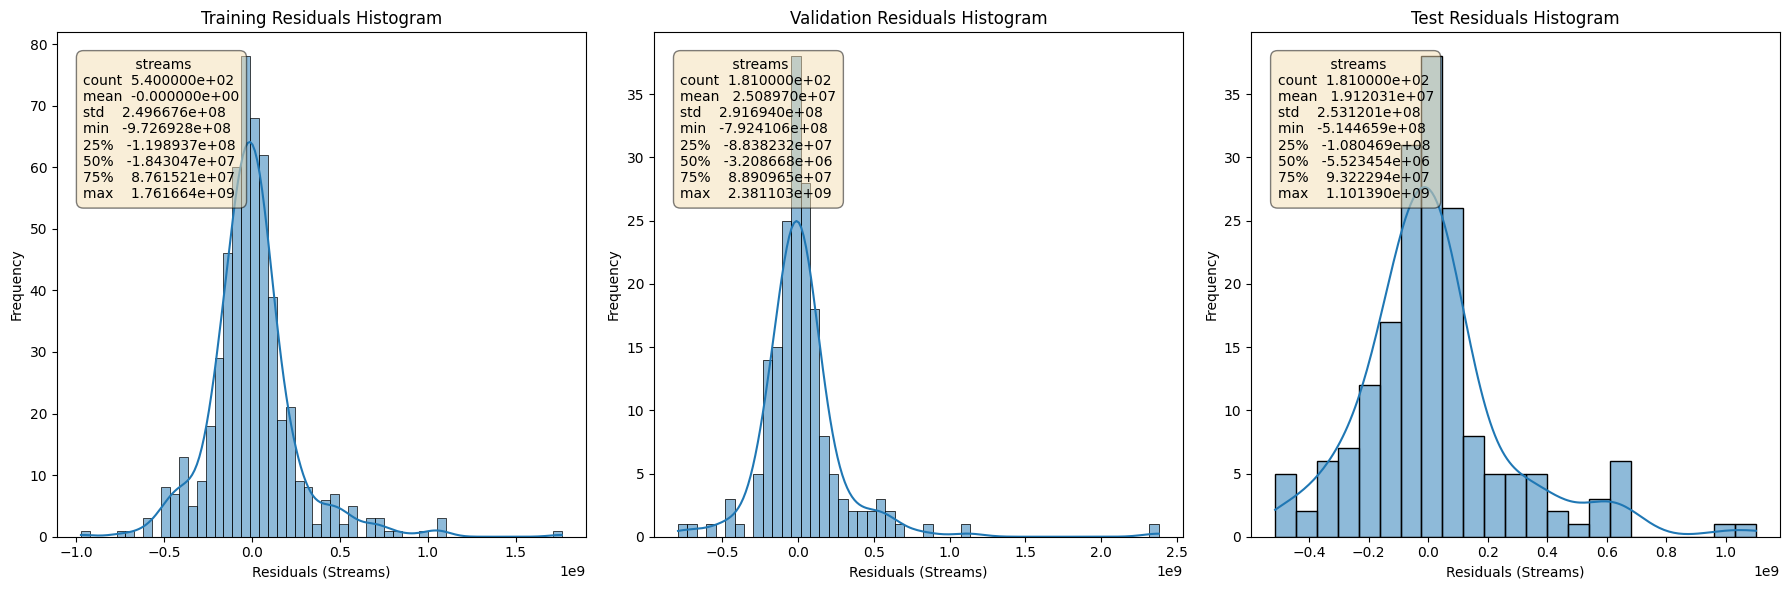

In [8]:
# Calculate residuals for each partition (Actual - Predicted)
train_residuals = y_train - y_train_pred
val_residuals = y_val - y_val_pred
test_residuals = y_test - y_test_pred

# Plot histograms of the residuals
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# 1. Training Residuals
sns.histplot(train_residuals, kde=True, ax=axs[0])
axs[0].set_title('Training Residuals Histogram')
axs[0].set_xlabel('Residuals (Streams)')
axs[0].set_ylabel('Frequency')
train_stats = pd.DataFrame(train_residuals).describe().round(2)
axs[0].text(0.05, 0.95, train_stats.to_string(), transform=axs[0].transAxes,
            va='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

# 2. Validation Residuals
sns.histplot(val_residuals, kde=True, ax=axs[1])
axs[1].set_title('Validation Residuals Histogram')
axs[1].set_xlabel('Residuals (Streams)')
axs[1].set_ylabel('Frequency')
val_stats = pd.DataFrame(val_residuals).describe().round(2)
axs[1].text(0.05, 0.95, val_stats.to_string(), transform=axs[1].transAxes,
            va='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

# 3. Test Residuals
sns.histplot(test_residuals, kde=True, ax=axs[2])
axs[2].set_title('Test Residuals Histogram')
axs[2].set_xlabel('Residuals (Streams)')
axs[2].set_ylabel('Frequency')
test_stats = pd.DataFrame(test_residuals).describe().round(2)
axs[2].text(0.05, 0.95, test_stats.to_string(), transform=axs[2].transAxes,
            va='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

Dataframes with actual and predicted streams successfully created.


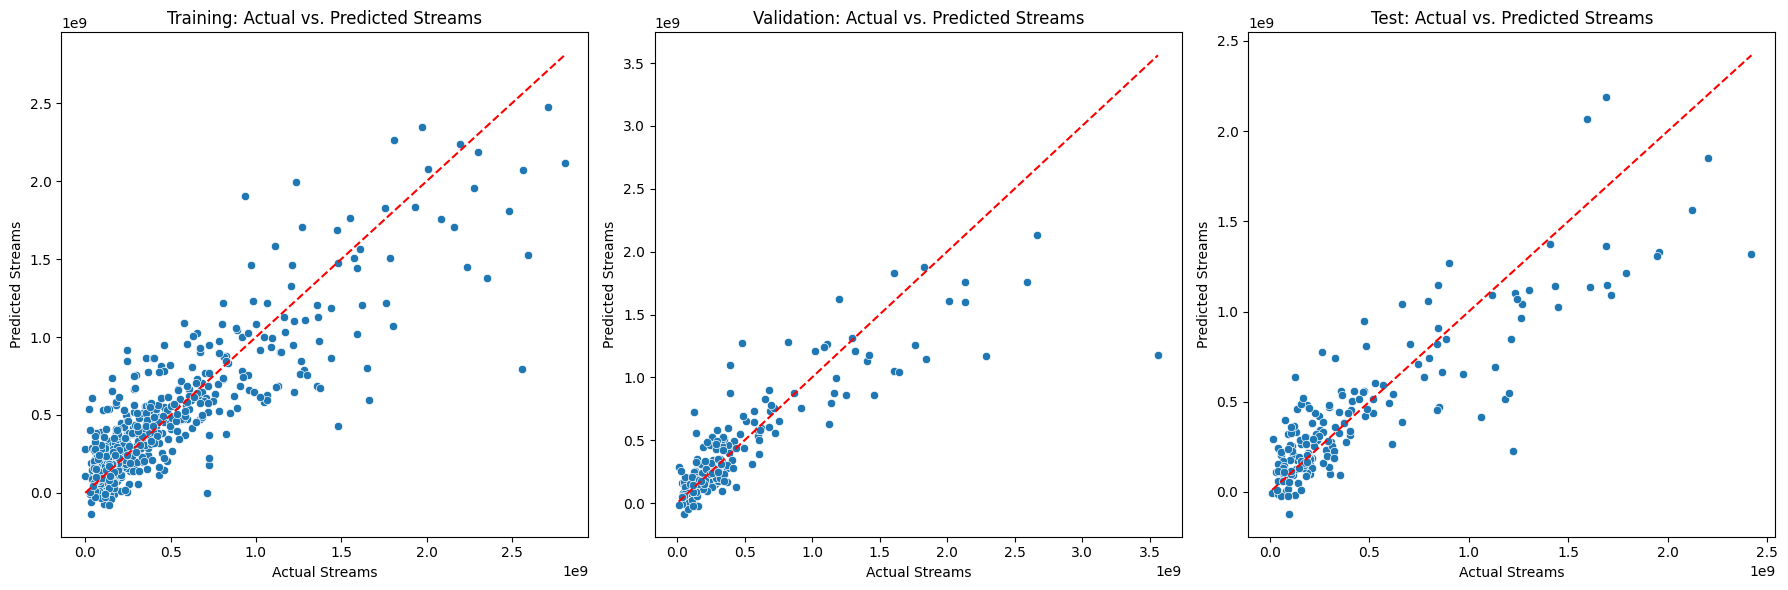

In [9]:
# Create dataframes combining actual features with actual and predicted streams
if 'train_results' not in locals() or 'val_results' not in locals() or 'test_results' not in locals():
    train_results = X_train.copy()
    train_results['Actual_Streams'] = y_train
    train_results['Predicted_Streams'] = y_train_pred

    val_results = X_val.copy()
    val_results['Actual_Streams'] = y_val
    val_results['Predicted_Streams'] = y_val_pred

    test_results = X_test.copy()
    test_results['Actual_Streams'] = y_test
    test_results['Predicted_Streams'] = y_test_pred

    print("Dataframes with actual and predicted streams successfully created.")

# Plot Actual vs. Predicted streams for each partition
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# 1. Training Partition Scatterplot
sns.scatterplot(x='Actual_Streams', y='Predicted_Streams', data=train_results, ax=axs[0])
axs[0].set_title('Training: Actual vs. Predicted Streams')
axs[0].set_xlabel('Actual Streams')
axs[0].set_ylabel('Predicted Streams')
axs[0].plot([train_results['Actual_Streams'].min(), train_results['Actual_Streams'].max()],
           [train_results['Actual_Streams'].min(), train_results['Actual_Streams'].max()],
           color='red', linestyle='--')

# 2. Validation Partition Scatterplot
sns.scatterplot(x='Actual_Streams', y='Predicted_Streams', data=val_results, ax=axs[1])
axs[1].set_title('Validation: Actual vs. Predicted Streams')
axs[1].set_xlabel('Actual Streams')
axs[1].set_ylabel('Predicted Streams')
axs[1].plot([val_results['Actual_Streams'].min(), val_results['Actual_Streams'].max()],
           [val_results['Actual_Streams'].min(), val_results['Actual_Streams'].max()],
           color='red', linestyle='--')

# 3. Test Partition Scatterplot
sns.scatterplot(x='Actual_Streams', y='Predicted_Streams', data=test_results, ax=axs[2])
axs[2].set_title('Test: Actual vs. Predicted Streams')
axs[2].set_xlabel('Actual Streams')
axs[2].set_ylabel('Predicted Streams')
axs[2].plot([test_results['Actual_Streams'].min(), test_results['Actual_Streams'].max()],
           [test_results['Actual_Streams'].min(), test_results['Actual_Streams'].max()],
           color='red', linestyle='--')

plt.tight_layout()
plt.show()

6. Comment on the model performance.  What did you observe in the results?


Looking at the histograms, the residuals are roughly centered around zero, but the distribution is not perfectly normal—it features very long tails, particularly on the right (positive) side. For instance, in our test partition, there is a massive negative residual (around -514 million), meaning the model drastically overpredicted a track's streams. However, there is an even larger positive residual of over 1.1 billion. This indicates that the model severely underpredicted the streams for at least one massive hit song. Extreme outliers like these are enough to heavily skew our overall error calculations and RMSE.

In these scatterplots, the goal is for the data points to fall as tightly along the red diagonal line as possible. A point landing perfectly on the red line means the actual and predicted streams match identically, resulting in zero error. Points above the line represent instances where the model underpredicted, while points below the line mean the prediction was too high.

When we examine the Test partition scatterplot, the data clusters decently at the lower end, but as the predicted streams increase, the points begin to fan out significantly. We can easily spot massive outliers pulling far away from the diagonal. Looking at one of the worst overpredictions, there is a song that actually accumulated around 261 million streams, yet our model confidently predicted it would reach nearly 775 million! Conversely, there are mega-hits where the model fell short by over a billion streams. This suggests our linear model does a decent job with 'average' songs but struggles to accurately capture the extreme viral success of outliers. It would be worth exploring these specific tracks to see if they possess unique characteristics not captured by our current predictors.

7. Check for predictor significance.  Are any predictors insignificant?  Which ones?


In [10]:
# Fit the model using statsmodels to get p-values and other statistics

# Create a copy to avoid modifying the original X_train
X_train_sm = X_train.copy()

# Add a constant to the features for the intercept
X_train_sm = sm.add_constant(X_train_sm)

# Initialize and fit the OLS model
model_sm = sm.OLS(y_train, X_train_sm).fit()

# Print the summary of the regression results
print(model_sm.summary())

# (Optional: Just printing the insignificant ones cleanly like before)
print("\n--- Insignificant Predictors (P-Value > 0.05) ---")
p_values = model_sm.pvalues
print(p_values[p_values > 0.05].round(4))

                            OLS Regression Results                            
Dep. Variable:                streams   R-squared:                       0.754
Model:                            OLS   Adj. R-squared:                  0.745
Method:                 Least Squares   F-statistic:                     79.70
Date:                Tue, 03 Mar 2026   Prob (F-statistic):          8.35e-144
Time:                        01:01:16   Log-Likelihood:                -11207.
No. Observations:                 540   AIC:                         2.246e+04
Df Residuals:                     519   BIC:                         2.255e+04
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                                                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------


Yes, a significant number of predictors in our current model are statistically insignificant. We determine this by looking at the P-values from the OLS regression summary. Using a standard Alpha level of 0.05, any predictor with a P-value greater than 0.05 is considered insignificant, meaning we fail to reject the null hypothesis and cannot mathematically prove it impacts the stream count.

Based on the output, the following predictors are insignificant:
* **Track Details:** `artist_count` (0.120), `released_day` (0.104), and the dummy variable `mode_Minor` (0.637).
* **Platform Metrics:** `in_apple_charts` (0.685), `in_deezer_playlists` (0.220), and `in_deezer_charts` (0.442).
* **Audio Characteristics:** Nearly all the technical audio features failed the significance test, including `bpm` (0.463), `danceability_%` (0.257), `energy_%` (0.166), `acousticness_%` (0.518), `instrumentalness_%` (0.281), `liveness_%` (0.780), and `speechiness_%` (0.478).

(Note: The constant/intercept also showed a P-value of 0.088, but we generally retain the intercept in regression models regardless of its individual significance).

This indicates our model is currently holding onto a lot of unnecessary complexity and could benefit from feature selection.

8. Re-train the model using just the statistically significant predictors.


In [11]:
# 1. Define the list of only the statistically significant features
significant_features = [
    'Johnson Su Transform to Normal released_year',
    'in_spotify_playlists',
    'in_spotify_charts',
    'in_apple_playlists',
    'in_shazam_charts',
    'valence_%',
    'released_month_reduced_Low'
]

# 2. Filter our existing partitions to only include these selected features
X_train_selected = X_train[significant_features]
X_val_selected = X_val[significant_features]
X_test_selected = X_test[significant_features]


# --- Rerun the Linear Regression model with the selected subset of predictors ---

# Initialize the Linear Regression model
model_selected = LinearRegression()

# Fit the model to the training data with selected features
model_selected.fit(X_train_selected, y_train)

# Make predictions on the training, validation, and test sets with selected features
y_train_pred_selected = model_selected.predict(X_train_selected)
y_val_pred_selected = model_selected.predict(X_val_selected)
y_test_pred_selected = model_selected.predict(X_test_selected)

# Evaluate the new model on the training, validation, and test sets
train_mse_selected = mean_squared_error(y_train, y_train_pred_selected)
val_mse_selected = mean_squared_error(y_val, y_val_pred_selected)
test_mse_selected = mean_squared_error(y_test, y_test_pred_selected)

# Calculate RMSE for the new model
train_rmse_selected = np.sqrt(train_mse_selected)
val_rmse_selected = np.sqrt(val_mse_selected)
test_rmse_selected = np.sqrt(test_mse_selected)

train_r2_selected = r2_score(y_train, y_train_pred_selected)
val_r2_selected = r2_score(y_val, y_val_pred_selected)
test_r2_selected = r2_score(y_test, y_test_pred_selected)

# Print the performance metrics for the new model
print("Model Performance with Selected Features:")
print(f"  Training Set - RMSE: {train_rmse_selected:.2f}, R-squared: {train_r2_selected:.2f}")
print(f"  Validation Set - RMSE: {val_rmse_selected:.2f}, R-squared: {val_r2_selected:.2f}")
print(f"  Test Set - RMSE: {test_rmse_selected:.2f}, R-squared: {test_r2_selected:.2f}")

# Print the model coefficients and intercept for the new model
print("\nModel Coefficients with Selected Features:")
for feature, coef in zip(X_train_selected.columns, model_selected.coef_):
    print(f"  {feature}: {coef:.2f}")

print(f"\nIntercept: {model_selected.intercept_:.2f}")

Model Performance with Selected Features:
  Training Set - RMSE: 253497394.04, R-squared: 0.75
  Validation Set - RMSE: 297210506.35, R-squared: 0.73
  Test Set - RMSE: 254122218.53, R-squared: 0.75

Model Coefficients with Selected Features:
  Johnson Su Transform to Normal released_year: -138144681.05
  in_spotify_playlists: 21078.00
  in_spotify_charts: 6454121.80
  in_apple_playlists: 2579109.27
  in_shazam_charts: -527495.59
  valence_%: -1534324.71
  released_month_reduced_Low: 56161886.44

Intercept: 223885350.46



The results of this new model perfectly illustrate the value of feature selection and the goal of building a parsimonious model.

Even though we dropped 13 insignificant predictor columns (reducing our features from 20 down to just 7), our predictive power remained incredibly stable. The Test R-squared stayed exactly the same at 0.75, meaning our simplified model is still explaining 75% of the variance in total streams. The Test RMSE only experienced a very minor increase (moving from 253,143,015 in the full model to 254,122,218 in this selected model).

Because we achieved the same level of accuracy using far fewer variables, this model is vastly superior to the complex one we built previously. It is less prone to overfitting and much easier to interpret.

Looking at the new coefficients, their impact remains consistent with our initial findings:
* Being on the Spotify charts (`in_spotify_charts`) adds roughly 6.45 million streams.
* Being released in a "Low" volume month (`released_month_reduced_Low`) adds over 56.1 million streams compared to the baseline.
* The intercept shifted slightly to 223,885,350 to adjust for the dropped variables, giving us our new, streamlined regression formula.

9. Check model performance again by partition with RMSE, R Squared, distribution of residuals, and actual by predicted plots.

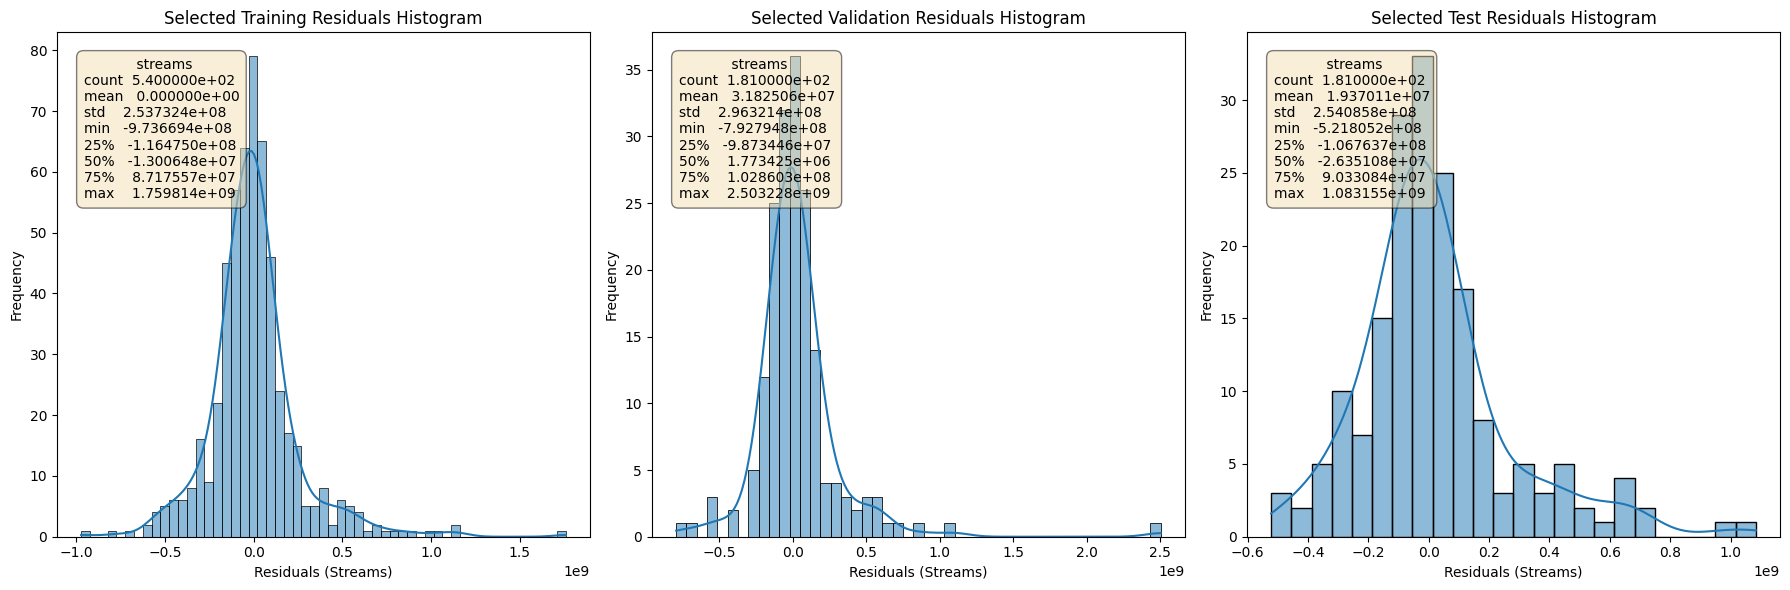

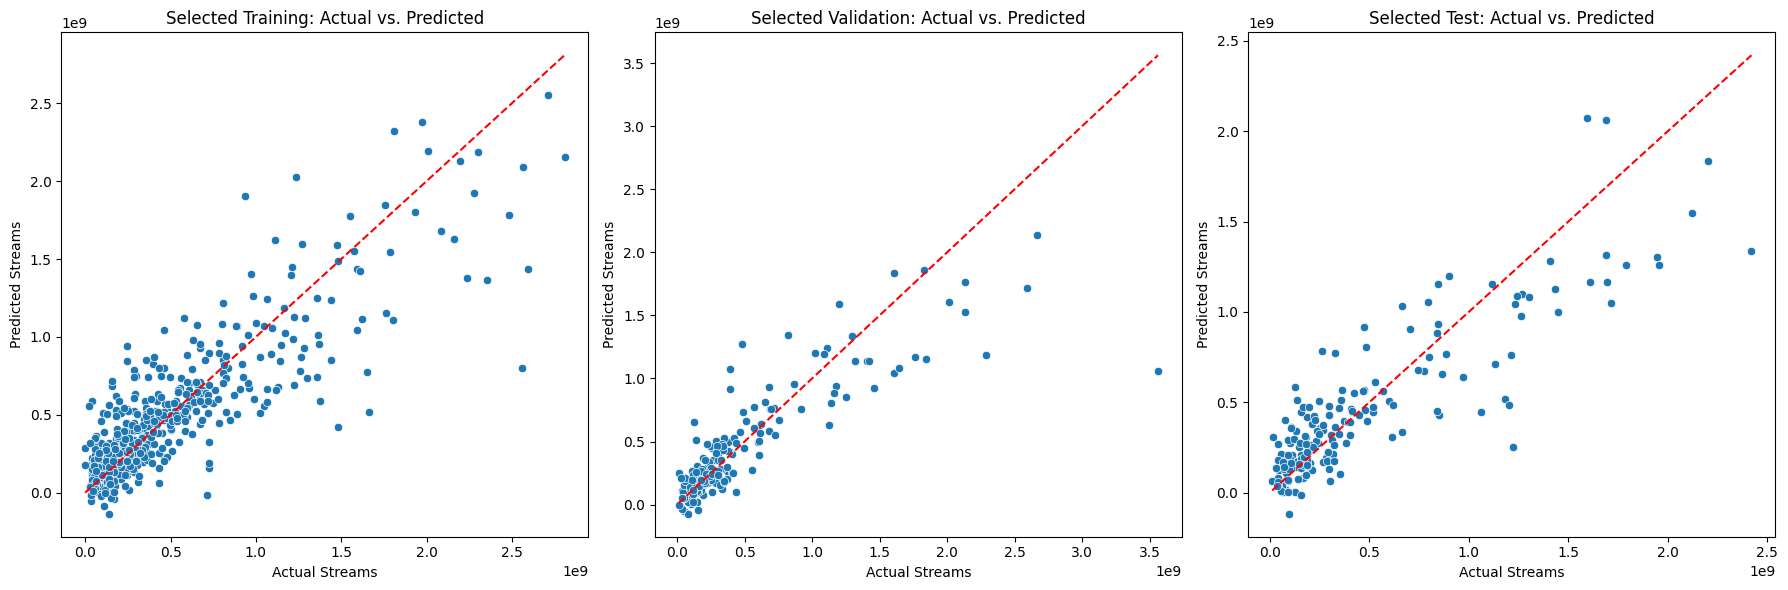

In [12]:
# 1. Calculate residuals for each partition of the SELECTED model
train_residuals_selected = y_train - y_train_pred_selected
val_residuals_selected = y_val - y_val_pred_selected
test_residuals_selected = y_test - y_test_pred_selected

# 2. Plot histograms of the residuals
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Training Residuals
sns.histplot(train_residuals_selected, kde=True, ax=axs[0])
axs[0].set_title('Selected Training Residuals Histogram')
axs[0].set_xlabel('Residuals (Streams)')
axs[0].set_ylabel('Frequency')
train_stats_sel = pd.DataFrame(train_residuals_selected).describe().round(2)
axs[0].text(0.05, 0.95, train_stats_sel.to_string(), transform=axs[0].transAxes,
            va='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

# Validation Residuals
sns.histplot(val_residuals_selected, kde=True, ax=axs[1])
axs[1].set_title('Selected Validation Residuals Histogram')
axs[1].set_xlabel('Residuals (Streams)')
axs[1].set_ylabel('Frequency')
val_stats_sel = pd.DataFrame(val_residuals_selected).describe().round(2)
axs[1].text(0.05, 0.95, val_stats_sel.to_string(), transform=axs[1].transAxes,
            va='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

# Test Residuals
sns.histplot(test_residuals_selected, kde=True, ax=axs[2])
axs[2].set_title('Selected Test Residuals Histogram')
axs[2].set_xlabel('Residuals (Streams)')
axs[2].set_ylabel('Frequency')
test_stats_sel = pd.DataFrame(test_residuals_selected).describe().round(2)
axs[2].text(0.05, 0.95, test_stats_sel.to_string(), transform=axs[2].transAxes,
            va='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# 3. Create dataframes combining actual streams and selected predictions
if 'train_results_sel' not in locals() or 'val_results_sel' not in locals() or 'test_results_sel' not in locals():
    train_results_sel = X_train_selected.copy()
    train_results_sel['Actual_Streams'] = y_train
    train_results_sel['Predicted_Streams'] = y_train_pred_selected

    val_results_sel = X_val_selected.copy()
    val_results_sel['Actual_Streams'] = y_val
    val_results_sel['Predicted_Streams'] = y_val_pred_selected

    test_results_sel = X_test_selected.copy()
    test_results_sel['Actual_Streams'] = y_test
    test_results_sel['Predicted_Streams'] = y_test_pred_selected

# 4. Plot Actual vs. Predicted streams for each partition
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Training Partition Scatterplot
sns.scatterplot(x='Actual_Streams', y='Predicted_Streams', data=train_results_sel, ax=axs[0])
axs[0].set_title('Selected Training: Actual vs. Predicted')
axs[0].set_xlabel('Actual Streams')
axs[0].set_ylabel('Predicted Streams')
axs[0].plot([train_results_sel['Actual_Streams'].min(), train_results_sel['Actual_Streams'].max()],
           [train_results_sel['Actual_Streams'].min(), train_results_sel['Actual_Streams'].max()],
           color='red', linestyle='--')

# Validation Partition Scatterplot
sns.scatterplot(x='Actual_Streams', y='Predicted_Streams', data=val_results_sel, ax=axs[1])
axs[1].set_title('Selected Validation: Actual vs. Predicted')
axs[1].set_xlabel('Actual Streams')
axs[1].set_ylabel('Predicted Streams')
axs[1].plot([val_results_sel['Actual_Streams'].min(), val_results_sel['Actual_Streams'].max()],
           [val_results_sel['Actual_Streams'].min(), val_results_sel['Actual_Streams'].max()],
           color='red', linestyle='--')

# Test Partition Scatterplot
sns.scatterplot(x='Actual_Streams', y='Predicted_Streams', data=test_results_sel, ax=axs[2])
axs[2].set_title('Selected Test: Actual vs. Predicted')
axs[2].set_xlabel('Actual Streams')
axs[2].set_ylabel('Predicted Streams')
axs[2].plot([test_results_sel['Actual_Streams'].min(), test_results_sel['Actual_Streams'].max()],
           [test_results_sel['Actual_Streams'].min(), test_results_sel['Actual_Streams'].max()],
           color='red', linestyle='--')

plt.tight_layout()
plt.show()

10. How did performance change?  Which model is better?



When comparing the original Full Model (20 predictors) to the new Parsimonious Model (7 predictors), the performance change was practically negligible:

* **Full Model (Test Set):** RMSE = 253,143,015.28 | R-squared = 0.75
* **Parsimonious Model (Test Set):** RMSE = 254,122,218.53 | R-squared = 0.75

By dropping 13 statistically insignificant predictors, the R-squared score remained exactly the same at 0.75 on the test partition, meaning both models explain 75% of the variance in streams. The Test RMSE saw a tiny increase of less than 1 million streams—a statistically insignificant difference when predicting totals in the hundreds of millions or billions.



**Which model is better?**
The Parsimonious Model is vastly superior. By achieving the exact same level of predictive accuracy with far fewer variables, it is a much stronger model. It is mathematically simpler, vastly easier to interpret for stakeholders, requires less computational power, and is significantly less prone to overfitting on new, unseen data.

Ultimately, keeping 13 extra "noise" columns in the Full Model added unnecessary complexity without improving accuracy. The streamlined, 7-predictor model is the clear winner.